# Prophet Forecasting for All Electricity Clients

This notebook trains one Prophet model for every client column in `dataset/LD2011_2014.txt`, excluding the timestamp column, using normalized 15-minute data.

The modelling setup:

- lookback window: 256 observations (64 hours),
- forecast horizon: 96 observations (24 hours),
- interval length: 15 minutes,
- one independent normalized Prophet model per client.

Prophet training, holdout evaluation, plots, metrics and saved forecasts all remain on the normalized z-score scale.

## 1. Setup

In [1]:
from pathlib import Path
import os
import time
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

In [2]:
# Paths
DATA_PATH = Path("dataset/LD2011_2014.txt")
OUTPUT_DIR = Path("outputs/prophet_all_normalized")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Native data frequency and fixed window sizes
RAW_FREQ = "15min"
FORECAST_FREQ = "15min"
LOOKBACK_WINDOW = 256             # 256 x 15 minutes = 64 hours
FORECAST_HORIZON = 96      # 96 x 15 minutes = 24 hours
REQUIRED_HISTORY_STEPS = LOOKBACK_WINDOW + FORECAST_HORIZON
REQUIRED_HISTORY_DAYS = REQUIRED_HISTORY_STEPS * 15 / (24 * 60)
RESAMPLE_METHOD = "mean"

# Preprocessing setup based on deep EDA findings
REPLACE_NON_POSITIVE_WITH_NA = True
INTERPOLATE_MISSING = True
CLIP_EXTREME_OUTLIERS = True
LOWER_CLIP_Q = 0.001
UPPER_CLIP_Q = 0.999

# Normalization setup
# The model uses z-score normalization per client: y_norm = (y - mean) / std.
# Holdout scalers are fitted on the 256-point training window.
NORMALIZATION_METHOD = "zscore"
MIN_STD = 1e-8

# Full run control
# Default is 0, which means use all client columns. Set to a small number for a quick smoke test.
SMOKE_TEST_N = int(os.getenv("PROPHET_ALL_NORMALIZED_SMOKE_N", "0"))

assert DATA_PATH.exists(), "Dataset not found: {}".format(DATA_PATH)
assert pd.Timedelta(FORECAST_FREQ) == pd.Timedelta(minutes=15)
assert LOOKBACK_WINDOW > 1 and FORECAST_HORIZON > 0

requested_settings = pd.Series(
    {
        "data_frequency": FORECAST_FREQ,
        "lookback_window": LOOKBACK_WINDOW,
        "lookback_duration_hours": LOOKBACK_WINDOW * 15 / 60,
        "forecast_horizon": FORECAST_HORIZON,
        "forecast_duration_hours": FORECAST_HORIZON * 15 / 60,
        "metrics": "MAE, MSE, RMSE, sMAPE",
    },
    name="requested_configuration",
)
requested_settings

data_frequency                             15min
lookback_window                              256
lookback_duration_hours                     64.0
forecast_horizon                              96
forecast_duration_hours                     24.0
metrics                    MAE, MSE, RMSE, sMAPE
Name: requested_configuration, dtype: object

## 2. Load and Validate the Full Dataset

In [3]:
raw_df = pd.read_csv(
    DATA_PATH,
    delimiter=";",
    decimal=",",
    parse_dates=[0],
    index_col=0,
    low_memory=False,
)

raw_df.index.name = "ds"
raw_df = raw_df.sort_index()
raw_df = raw_df[~raw_df.index.duplicated(keep="last")]
raw_df = raw_df.apply(pd.to_numeric, errors="coerce")

target_columns = list(raw_df.columns)

print(f"Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]:,} client columns")
print(f"Time range: {raw_df.index.min()} to {raw_df.index.max()}")
print(f"Missing values: {raw_df.isna().sum().sum():,}")
print(f"Most common time step: {pd.Series(raw_df.index).diff().dropna().mode().iloc[0]}")
print(f"Non-{RAW_FREQ} gaps: {(pd.Series(raw_df.index).diff().dropna() != pd.Timedelta(RAW_FREQ)).sum():,}")
raw_df.head()

Shape: 140,256 rows x 370 client columns
Time range: 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Missing values: 0
Most common time step: 0 days 00:15:00
Non-15min gaps: 0


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
selected_columns = target_columns if SMOKE_TEST_N <= 0 else target_columns[:SMOKE_TEST_N]

print(f"Total available client columns: {len(target_columns)}")
print(f"Columns selected for this run: {len(selected_columns)}")
if SMOKE_TEST_N > 0:
    print(f"Smoke-test mode is active: first {SMOKE_TEST_N} columns only")

Total available client columns: 370
Columns selected for this run: 370


## 3. Client Activity Summary

The deeper EDA showed that many clients are late starters. Leading zero stretches are therefore treated as inactive history rather than true zero consumption.


In [5]:
activity_rows = []
for col in target_columns:
    positive_mask = raw_df[col] > 0
    first_active = raw_df.index[positive_mask.argmax()] if positive_mask.any() else pd.NaT
    last_active = raw_df.index[len(positive_mask) - positive_mask[::-1].argmax() - 1] if positive_mask.any() else pd.NaT
    activity_rows.append(
        {
            "client": col,
            "first_active": first_active,
            "last_active": last_active,
            "positive_readings": int(positive_mask.sum()),
            "zero_fraction": float((raw_df[col] == 0).mean()),
            "mean_load": float(raw_df[col].mean()),
            "total_load": float(raw_df[col].sum()),
        }
    )

activity_df = pd.DataFrame(activity_rows).set_index("client")
activity_df["active_from_day_1"] = activity_df["first_active"] <= raw_df.index.min() + pd.Timedelta(days=1)
activity_df["history_days_after_first_active"] = (
    raw_df.index.max() - activity_df["first_active"]
).dt.total_seconds() / (24 * 3600)

print(f"Always active clients: {activity_df['active_from_day_1'].sum()}")
print(f"Late starters: {(~activity_df['active_from_day_1']).sum()}")
print(f"Never active clients: {activity_df['first_active'].isna().sum()}")
activity_df.sort_values("total_load", ascending=False).head(10)

Always active clients: 158
Late starters: 212
Never active clients: 0


,first_active,last_active,positive_readings,zero_fraction,mean_load,total_load,active_from_day_1,history_days_after_first_active
client,,,,,,,,
MT_362,2012-01-01 00:15:00,2015-01-01,105138,0.250385,37607.987537,5.274746e+09,False,1095.989583
MT_196,2011-01-01 00:15:00,2015-01-01,140234,0.000157,20744.150874,2.909492e+09,True,1460.989583
MT_279,2011-01-01 00:15:00,2015-01-01,140160,0.000684,12038.971232,1.688538e+09,True,1460.989583
MT_370,2013-01-01 00:15:00,2015-01-01,69927,0.501433,8722.355145,1.223363e+09,False,729.989583
MT_208,2011-01-01 00:15:00,2015-01-01,140234,0.000157,6662.030067,9.343897e+08,True,1460.989583
MT_228,2011-01-01 00:15:00,2015-01-01,140244,0.000086,5782.656826,8.110523e+08,True,1460.989583
MT_220,2011-01-01 00:15:00,2015-01-01,140241,0.000107,2951.449898,4.139586e+08,True,1460.989583
MT_364,2012-01-01 00:15:00,2015-01-01,105157,0.250250,2940.031734,4.123571e+08,False,1095.989583
MT_194,2011-01-01 00:15:00,2015-01-01,140232,0.000171,2675.000006,3.751848e+08,True,1460.989583


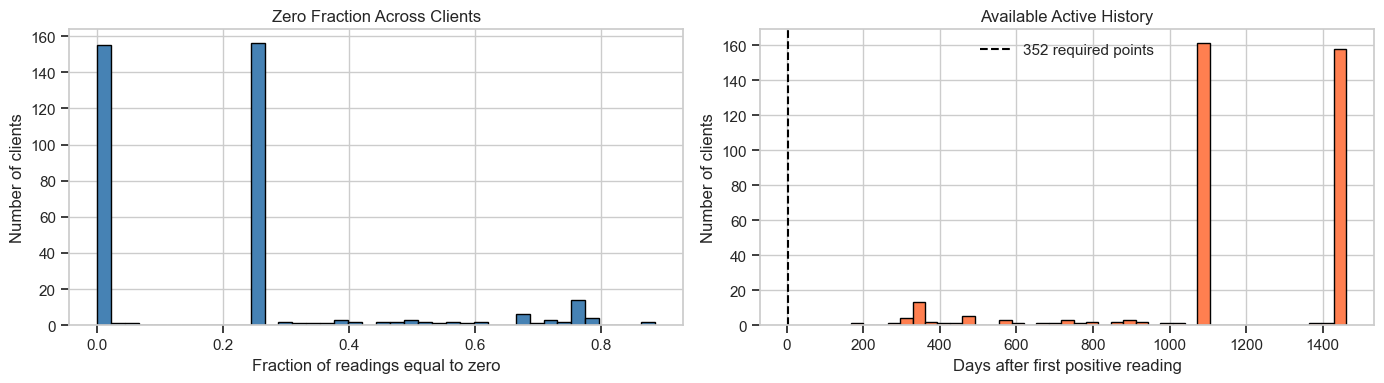

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

activity_df["zero_fraction"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Zero Fraction Across Clients")
axes[0].set_xlabel("Fraction of readings equal to zero")
axes[0].set_ylabel("Number of clients")

activity_df["history_days_after_first_active"].hist(bins=40, ax=axes[1], color="coral", edgecolor="black")
axes[1].axvline(REQUIRED_HISTORY_DAYS, color="black", linestyle="--", label=f"{REQUIRED_HISTORY_STEPS} required points")
axes[1].set_title("Available Active History")
axes[1].set_xlabel("Days after first positive reading")
axes[1].set_ylabel("Number of clients")
axes[1].legend()

plt.tight_layout()

## 4. Activation-Aware Preprocessing

Preprocessing decisions:

- enforce the native regular 15-minute grid,
- replace non-positive readings with missing values because EDA found activation-related zero stretches and zero DST/outage artifacts,
- retain 15-minute resolution,
- interpolate missing values only after each client's first active timestamp,
- clip extreme values using conservative per-client quantiles.

Each client needs at least 352 valid observations: 256 for the lookback window and 96 for holdout evaluation.

In [7]:
def preprocess_all_clients(raw: pd.DataFrame, activity: pd.DataFrame) -> pd.DataFrame:
    regular = raw.asfreq(RAW_FREQ)
    cleaned = regular.copy()

    if REPLACE_NON_POSITIVE_WITH_NA:
        cleaned = cleaned.mask(cleaned <= 0)

    if RESAMPLE_METHOD == "mean":
        processed = cleaned.resample(FORECAST_FREQ).mean()
    elif RESAMPLE_METHOD == "sum":
        processed = cleaned.resample(FORECAST_FREQ).sum(min_count=1)
    else:
        raise ValueError("RESAMPLE_METHOD must be either 'mean' or 'sum'.")

    processed.index.name = "ds"

    for col in processed.columns:
        first_active = activity.loc[col, "first_active"]
        if pd.isna(first_active):
            processed[col] = np.nan
            continue

        active_start = first_active.floor(FORECAST_FREQ)
        s = processed[col].copy()
        s.loc[s.index < active_start] = np.nan

        active_part = s.loc[s.index >= active_start].copy()
        if INTERPOLATE_MISSING:
            active_part = active_part.interpolate(method="time").ffill().bfill()

        if CLIP_EXTREME_OUTLIERS and active_part.notna().sum() > 10:
            lower, upper = active_part.quantile([LOWER_CLIP_Q, UPPER_CLIP_Q])
            active_part = active_part.clip(lower=lower, upper=upper)

        s.loc[s.index >= active_start] = active_part
        processed[col] = s

    return processed

processed_15min = preprocess_all_clients(raw_df, activity_df)

print(f"Processed 15-minute shape: {processed_15min.shape}")
print(f"Date range: {processed_15min.index.min()} to {processed_15min.index.max()}")
print(f"Total missing cells: {processed_15min.isna().sum().sum():,}")
processed_15min.head()

Processed 15-minute shape: (140256, 370)
Date range: 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Total missing cells: 9,958,262


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
preprocess_summary = activity_df.copy()
preprocess_summary["observations_non_missing"] = processed_15min.notna().sum()
preprocess_summary["observations_missing"] = processed_15min.isna().sum()
preprocess_summary["series_start"] = processed_15min.apply(lambda s: s.first_valid_index())
preprocess_summary["series_end"] = processed_15min.apply(lambda s: s.last_valid_index())
preprocess_summary["history_days"] = (
    preprocess_summary["series_end"] - preprocess_summary["series_start"]
).dt.total_seconds() / (24 * 3600)
preprocess_summary["eligible_for_prophet"] = preprocess_summary["observations_non_missing"] >= REQUIRED_HISTORY_STEPS

print(preprocess_summary["eligible_for_prophet"].value_counts().rename(index={True: "eligible", False: "not eligible"}))
preprocess_summary.sort_values("total_load", ascending=False).head(10)

eligible_for_prophet
eligible    370
Name: count, dtype: int64


,first_active,last_active,positive_readings,zero_fraction,mean_load,total_load,active_from_day_1,history_days_after_first_active,observations_non_missing,observations_missing,series_start,series_end,history_days,eligible_for_prophet
client,,,,,,,,,,,,,,
MT_362,2012-01-01 00:15:00,2015-01-01,105138,0.250385,37607.987537,5.274746e+09,False,1095.989583,105216,35040,2012-01-01 00:15:00,2015-01-01,1095.989583,True
MT_196,2011-01-01 00:15:00,2015-01-01,140234,0.000157,20744.150874,2.909492e+09,True,1460.989583,140256,0,2011-01-01 00:15:00,2015-01-01,1460.989583,True
MT_279,2011-01-01 00:15:00,2015-01-01,140160,0.000684,12038.971232,1.688538e+09,True,1460.989583,140256,0,2011-01-01 00:15:00,2015-01-01,1460.989583,True
MT_370,2013-01-01 00:15:00,2015-01-01,69927,0.501433,8722.355145,1.223363e+09,False,729.989583,70080,70176,2013-01-01 00:15:00,2015-01-01,729.989583,True
MT_208,2011-01-01 00:15:00,2015-01-01,140234,0.000157,6662.030067,9.343897e+08,True,1460.989583,140256,0,2011-01-01 00:15:00,2015-01-01,1460.989583,True
MT_228,2011-01-01 00:15:00,2015-01-01,140244,0.000086,5782.656826,8.110523e+08,True,1460.989583,140256,0,2011-01-01 00:15:00,2015-01-01,1460.989583,True
MT_220,2011-01-01 00:15:00,2015-01-01,140241,0.000107,2951.449898,4.139586e+08,True,1460.989583,140256,0,2011-01-01 00:15:00,2015-01-01,1460.989583,True
MT_364,2012-01-01 00:15:00,2015-01-01,105157,0.250250,2940.031734,4.123571e+08,False,1095.989583,105216,35040,2012-01-01 00:15:00,2015-01-01,1095.989583,True
MT_194,2011-01-01 00:15:00,2015-01-01,140232,0.000171,2675.000006,3.751848e+08,True,1460.989583,140256,0,2011-01-01 00:15:00,2015-01-01,1460.989583,True


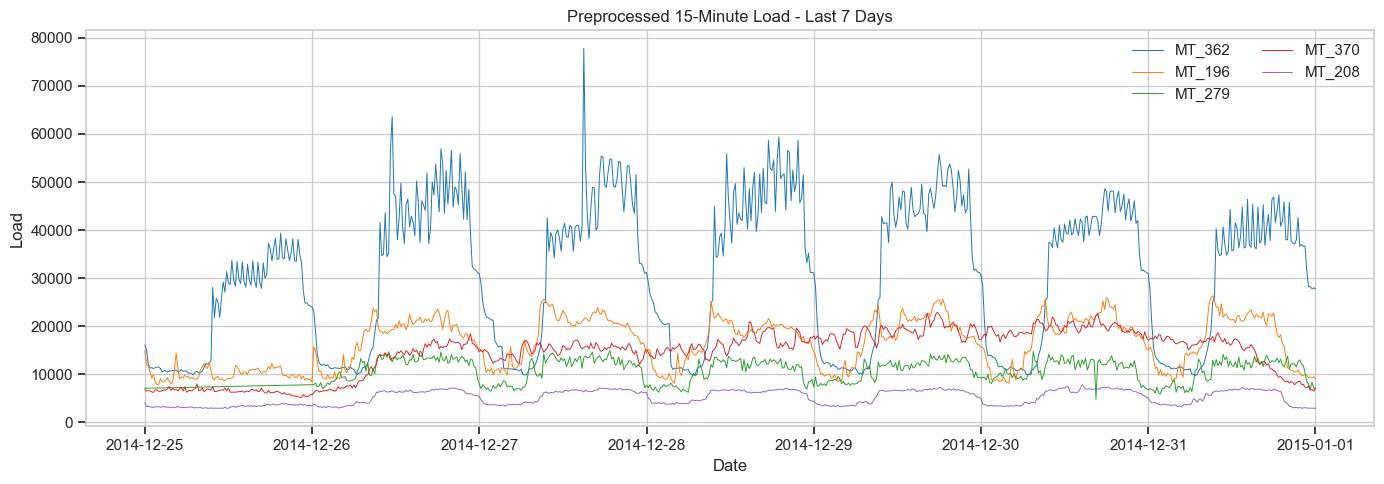

In [9]:
top_clients = preprocess_summary.sort_values("total_load", ascending=False).head(10).index.tolist()
plot_cols = top_clients[:5]
plot_start = processed_15min.index.max() - pd.Timedelta(days=7)

fig, ax = plt.subplots(figsize=(14, 5))
for col in plot_cols:
    ax.plot(
        processed_15min.loc[plot_start:, col].index,
        processed_15min.loc[plot_start:, col],
        linewidth=0.7,
        label=col,
    )
ax.set_title("Preprocessed 15-Minute Load - Last 7 Days")
ax.set_xlabel("Date")
ax.set_ylabel("Load")
ax.legend(ncol=2)
plt.tight_layout()

## 5. Normalize the Preprocessed 15-Minute Data

The normalized data uses per-client z-score scaling:

`y_norm = (y - mean) / std`

For comparision with Patchtst, the full preprocessed series is normalized. During model evaluation, the scaler is fitted only on the 256-point training window, preventing leakage from the following 96-point forecast window.

In [10]:
def fit_zscore_scaler(values: pd.Series) -> dict:
    clean = values.dropna().astype(float)
    mean = clean.mean()
    std = clean.std(ddof=0)
    if not np.isfinite(std) or std < MIN_STD:
        std = np.nan
    return {"mean": float(mean), "std": float(std)}


def transform_values(values: pd.Series, scaler: dict) -> pd.Series:
    return (values.astype(float) - scaler["mean"]) / scaler["std"]


normalization_rows = []
normalized_15min = processed_15min.copy()

for col in processed_15min.columns:
    scaler = fit_zscore_scaler(processed_15min[col])
    normalization_rows.append({"client": col, "mean": scaler["mean"], "std": scaler["std"]})
    if np.isfinite(scaler["std"]):
        normalized_15min[col] = transform_values(processed_15min[col], scaler)
    else:
        normalized_15min[col] = np.nan

normalization_df = pd.DataFrame(normalization_rows).set_index("client")
normalization_df.to_csv(OUTPUT_DIR / "prophet_all_normalized_scalers_full_history.csv")

print(f"Normalized 15-minute shape: {normalized_15min.shape}")
print(f"Clients with valid full-history scaler: {normalization_df['std'].notna().sum()} / {len(normalization_df)}")
normalization_df.head()

Normalized 15-minute shape: (140256, 370)
Clients with valid full-history scaler: 370 / 370


,mean,std
client,,
MT_001,5.374386,6.318128
MT_002,27.677413,6.530189
MT_003,3.898389,12.558835
MT_004,109.557281,38.970779
MT_005,49.642315,17.786280


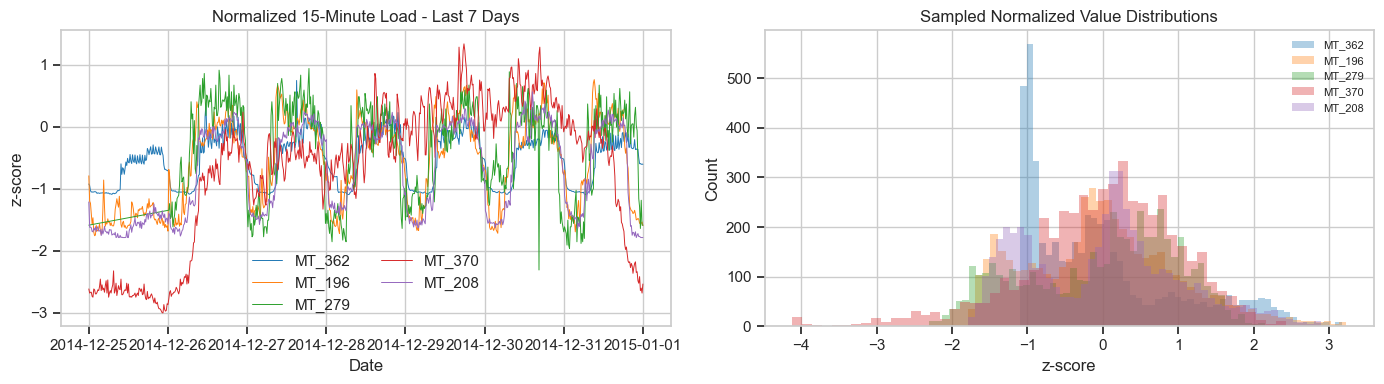

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_start = normalized_15min.index.max() - pd.Timedelta(days=7)
for col in plot_cols:
    axes[0].plot(
        normalized_15min.loc[plot_start:, col].index,
        normalized_15min.loc[plot_start:, col],
        linewidth=0.7,
        label=col,
    )
axes[0].set_title("Normalized 15-Minute Load - Last 7 Days")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("z-score")
axes[0].legend(ncol=2)

for col in plot_cols:
    available = normalized_15min[col].dropna()
    sample = available.sample(min(5000, len(available)), random_state=42)
    axes[1].hist(sample, bins=50, alpha=0.35, label=col)
axes[1].set_title("Sampled Normalized Value Distributions")
axes[1].set_xlabel("z-score")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=8)

plt.tight_layout()

## 6. Prophet Modelling Functions

One independent Prophet model is fitted for each client on normalized 15-minute values.

The 256-point lookback covers only 64 hours. Therefore the model includes seasonalities that can be learned within this window:

- 6-hour,
- 8-hour,
- 12-hour,
- daily.

Weekly, monthly, and yearly seasonalities are disabled because the lookback window is too short to estimate them.

In [12]:
try:
    from prophet import Prophet
except ImportError as exc:
    raise ImportError(
        "Prophet is required for this notebook. Install it with `%pip install prophet` and rerun."
    ) from exc

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda iterable, **kwargs: iterable

In [13]:
def build_prophet_model() -> Prophet:
    model = Prophet(
        growth="linear",
        daily_seasonality=True,
        weekly_seasonality=False,
        yearly_seasonality=False,
        seasonality_mode="additive",
        seasonality_prior_scale=10.0,
        changepoint_prior_scale=0.05,
        interval_width=0.80,
    )
    model.add_seasonality(name="six_hour", period=0.25, fourier_order=3)
    model.add_seasonality(name="eight_hour", period=1 / 3, fourier_order=3)
    model.add_seasonality(name="semi_daily", period=0.5, fourier_order=3)
    return model


def prepare_client_frame(processed: pd.DataFrame, client: str) -> pd.DataFrame:
    client_df = processed[[client]].dropna().rename(columns={client: "y"}).reset_index()
    client_df["y"] = client_df["y"].astype(float)
    return client_df


def evaluate_normalized_predictions(actual: pd.Series, predicted: pd.Series) -> dict:
    actual = actual.astype(float)
    predicted = predicted.astype(float)
    mse = mean_squared_error(actual, predicted)
    denominator = np.abs(actual) + np.abs(predicted)
    smape = 200 * np.mean(np.abs(actual - predicted) / np.maximum(denominator, 1e-8))
    return {
        "mae": mean_absolute_error(actual, predicted),
        "mse": mse,
        "rmse": np.sqrt(mse),
        "smape_pct": smape,
    }


def fit_evaluate_forecast_client(client: str, processed: pd.DataFrame) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    client_df = prepare_client_frame(processed, client)
    history_days = (client_df["ds"].max() - client_df["ds"].min()).total_seconds() / (24 * 3600) if len(client_df) else 0

    base_result = {
        "client": client,
        "status": "ok",
        "n_obs": len(client_df),
        "history_days": history_days,
        "lookback_window": LOOKBACK_WINDOW,
        "forecast_horizon": FORECAST_HORIZON,
        "train_rows": 0,
        "test_rows": 0,
        "fit_seconds_holdout": np.nan,
        "fit_seconds_final": np.nan,
        "fit_seconds_total": np.nan,
        "train_mean": np.nan,
        "train_std": np.nan,
        "final_mean": np.nan,
        "final_std": np.nan,
        "mae": np.nan,
        "mse": np.nan,
        "rmse": np.nan,
        "smape_pct": np.nan,
        "error": "",
    }

    if len(client_df) < REQUIRED_HISTORY_STEPS:
        base_result["status"] = "skipped"
        base_result["error"] = f"Fewer than {REQUIRED_HISTORY_STEPS} valid 15-minute observations"
        return base_result, pd.DataFrame(), pd.DataFrame()

    evaluation_window = client_df.tail(REQUIRED_HISTORY_STEPS).reset_index(drop=True)
    train_df = evaluation_window.iloc[:LOOKBACK_WINDOW].copy()
    test_df = evaluation_window.iloc[LOOKBACK_WINDOW:].copy()

    train_scaler = fit_zscore_scaler(train_df["y"])
    if not np.isfinite(train_scaler["std"]):
        base_result["status"] = "skipped"
        base_result["error"] = "Training window has near-zero variance after preprocessing"
        return base_result, pd.DataFrame(), pd.DataFrame()

    train_norm = train_df[["ds"]].copy()
    train_norm["y"] = transform_values(train_df["y"], train_scaler)
    test_norm = test_df[["ds"]].copy()
    test_norm["y"] = transform_values(test_df["y"], train_scaler)

    start_time = time.time()
    model = build_prophet_model()
    model.fit(train_norm)
    fit_seconds_holdout = time.time() - start_time

    holdout_forecast = model.predict(test_norm[["ds"]])
    holdout_df = test_norm.copy()
    holdout_df["yhat"] = holdout_forecast["yhat"].values
    holdout_df["yhat_lower"] = holdout_forecast["yhat_lower"].values
    holdout_df["yhat_upper"] = holdout_forecast["yhat_upper"].values
    holdout_df.insert(0, "client", client)

    metrics = evaluate_normalized_predictions(holdout_df["y"], holdout_df["yhat"])

    final_train_df = client_df.tail(LOOKBACK_WINDOW).copy()
    final_scaler = fit_zscore_scaler(final_train_df["y"])
    if not np.isfinite(final_scaler["std"]):
        base_result["status"] = "skipped"
        base_result["error"] = "Final lookback window has near-zero variance after preprocessing"
        return base_result, pd.DataFrame(), pd.DataFrame()

    final_train_norm = final_train_df[["ds"]].copy()
    final_train_norm["y"] = transform_values(final_train_df["y"], final_scaler)

    start_time = time.time()
    final_model = build_prophet_model()
    final_model.fit(final_train_norm)
    fit_seconds_final = time.time() - start_time

    future = final_model.make_future_dataframe(
        periods=FORECAST_HORIZON,
        freq=FORECAST_FREQ,
        include_history=False,
    )
    future_forecast = final_model.predict(future)
    forecast_cols = [
        "ds", "yhat", "yhat_lower", "yhat_upper", "trend",
        "six_hour", "eight_hour", "semi_daily", "daily",
    ]
    future_df = future_forecast[forecast_cols].copy()
    future_df.insert(0, "client", client)

    base_result.update(metrics)
    base_result.update(
        {
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "fit_seconds_holdout": fit_seconds_holdout,
            "fit_seconds_final": fit_seconds_final,
            "fit_seconds_total": fit_seconds_holdout + fit_seconds_final,
            "train_mean": train_scaler["mean"],
            "train_std": train_scaler["std"],
            "final_mean": final_scaler["mean"],
            "final_std": final_scaler["std"],
        }
    )
    return base_result, holdout_df, future_df

## 7. Train Normalized Prophet for All Client Columns

For every client, the holdout model uses 256 normalized 15-minute observations to forecast the next 96 observations. The final model uses the latest 256 observations and forecasts the next 96 intervals, exactly one day.

With the default configuration, this runs for all 370 clients.

In [14]:
results = []
holdout_frames = []
future_frames = []

run_columns = selected_columns
print(f"Starting normalized Prophet run for {len(run_columns)} client columns...")
print(f"Lookback: {LOOKBACK_WINDOW} x 15-minute observations")
print(f"Forecast horizon: {FORECAST_HORIZON} x 15-minute observations")
print(f"Outputs will be saved in: {OUTPUT_DIR.resolve()}")

for i, client in enumerate(tqdm(run_columns, desc="Normalized Prophet models"), start=1):
    try:
        result, holdout_df, future_df = fit_evaluate_forecast_client(client, processed_15min)
    except Exception as exc:
        result = {
            "client": client,
            "status": "failed",
            "n_obs": np.nan,
            "history_days": np.nan,
            "lookback_window": LOOKBACK_WINDOW,
            "forecast_horizon": FORECAST_HORIZON,
            "train_rows": 0,
            "test_rows": 0,
            "fit_seconds_holdout": np.nan,
            "fit_seconds_final": np.nan,
            "fit_seconds_total": np.nan,
            "train_mean": np.nan,
            "train_std": np.nan,
            "final_mean": np.nan,
            "final_std": np.nan,
            "mae": np.nan,
            "mse": np.nan,
            "rmse": np.nan,
            "smape_pct": np.nan,
            "error": repr(exc),
        }
        holdout_df = pd.DataFrame()
        future_df = pd.DataFrame()

    results.append(result)
    if not holdout_df.empty:
        holdout_frames.append(holdout_df)
    if not future_df.empty:
        future_frames.append(future_df)

    pd.DataFrame(results).to_csv(OUTPUT_DIR / "prophet_all_normalized_metrics_partial.csv", index=False)

metrics_df = pd.DataFrame(results).sort_values(["status", "mse"], na_position="last").reset_index(drop=True)
holdout_predictions_df = pd.concat(holdout_frames, ignore_index=True) if holdout_frames else pd.DataFrame()
future_forecasts_df = pd.concat(future_frames, ignore_index=True) if future_frames else pd.DataFrame()

metrics_df.to_csv(OUTPUT_DIR / "prophet_all_normalized_metrics.csv", index=False)
holdout_predictions_df.to_csv(OUTPUT_DIR / "prophet_all_normalized_holdout_predictions.csv", index=False)
future_forecasts_df.to_csv(OUTPUT_DIR / "prophet_all_normalized_future_forecasts.csv", index=False)

print("Run complete.")
print(metrics_df["status"].value_counts(dropna=False))
metrics_df.head(10)

Starting normalized Prophet run for 370 client columns...
Lookback: 256 x 15-minute observations
Forecast horizon: 96 x 15-minute observations
Outputs will be saved in: /Users/adriannabartoszek/Documents/studia/semestr VI - deg/DL/p/outputs/prophet_all_normalized


Normalized Prophet models:   0%|          | 0/370 [00:00<?, ?it/s]

14:01:13 - cmdstanpy - INFO - Chain [1] start processing
14:01:13 - cmdstanpy - INFO - Chain [1] done processing
14:01:14 - cmdstanpy - INFO - Chain [1] start processing
14:01:14 - cmdstanpy - INFO - Chain [1] done processing
14:01:14 - cmdstanpy - INFO - Chain [1] start processing
14:01:14 - cmdstanpy - INFO - Chain [1] done processing
14:01:14 - cmdstanpy - INFO - Chain [1] start processing
14:01:14 - cmdstanpy - INFO - Chain [1] done processing
14:01:14 - cmdstanpy - INFO - Chain [1] start processing
14:01:14 - cmdstanpy - INFO - Chain [1] done processing
14:01:14 - cmdstanpy - INFO - Chain [1] start processing
14:01:14 - cmdstanpy - INFO - Chain [1] done processing
14:01:14 - cmdstanpy - INFO - Chain [1] start processing
14:01:14 - cmdstanpy - INFO - Chain [1] done processing
14:01:14 - cmdstanpy - INFO - Chain [1] start processing
14:01:14 - cmdstanpy - INFO - Chain [1] done processing
14:01:14 - cmdstanpy - INFO - Chain [1] start processing
14:01:14 - cmdstanpy - INFO - Chain [1]

Run complete.
status
ok         366
skipped      4
Name: count, dtype: int64


,client,status,n_obs,history_days,lookback_window,forecast_horizon,train_rows,test_rows,fit_seconds_holdout,fit_seconds_final,fit_seconds_total,train_mean,train_std,final_mean,final_std,mae,mse,rmse,smape_pct,error
0,MT_151,ok,105216,1095.989583,256,96,256,96,0.047260,0.051404,0.098664,89.976955,40.207807,105.488731,37.864235,0.175466,0.055911,0.236455,34.299203,
1,MT_362,ok,105216,1095.989583,256,96,256,96,0.051103,0.050276,0.101379,34290.234375,15172.053048,32667.578125,13941.742754,0.217639,0.064367,0.253706,47.425566,
2,MT_229,ok,140256,1460.989583,256,96,256,96,0.050053,0.048773,0.098826,1003.193827,196.172589,1014.604666,207.666854,0.212951,0.066984,0.258814,30.679478,
3,MT_246,ok,140256,1460.989583,256,96,256,96,0.051067,0.047454,0.098521,566.455200,155.569205,561.303164,153.832451,0.219336,0.080806,0.284264,36.356153,
4,MT_155,ok,105216,1095.989583,256,96,256,96,0.049302,0.048913,0.098215,143.283420,113.843132,180.750868,102.175815,0.229510,0.093421,0.305648,56.776292,
5,MT_027,ok,105216,1095.989583,256,96,256,96,0.067483,0.052777,0.120260,30.843198,10.858707,31.756718,10.877704,0.256615,0.106758,0.326739,58.376882,
6,MT_070,ok,105216,1095.989583,256,96,256,96,0.047170,0.050842,0.098012,48.816430,17.193646,52.348428,17.258993,0.250919,0.109230,0.330499,65.063087,
7,MT_313,ok,140256,1460.989583,256,96,256,96,0.045629,0.061803,0.107432,213.838973,57.077845,215.519424,53.044288,0.262459,0.113513,0.336917,44.106061,
8,MT_034,ok,105216,1095.989583,256,96,256,96,0.052428,0.044428,0.096856,22.215433,6.784977,22.960130,6.882573,0.262097,0.114196,0.337929,63.190854,
9,MT_062,ok,105216,1095.989583,256,96,256,96,0.059854,0.055956,0.115810,87.577801,22.077028,88.991183,23.244151,0.285039,0.119268,0.345352,65.541876,


## 8. Evaluation Summary

All metrics are calculated directly on normalized z-score values for the 96-step holdout horizon.

- MAE: mean absolute error,
- MSE: mean squared error,
- RMSE: square root of MSE,
- sMAPE: symmetric percentage-style diagnostic.


In [15]:
successful_metrics = metrics_df[metrics_df["status"] == "ok"].copy()

summary_cols = [
    "mae", "mse", "rmse", "smape_pct",
    "fit_seconds_total", "history_days", "train_std", "final_std",
]
summary_metrics = successful_metrics[summary_cols].describe().T if len(successful_metrics) else pd.DataFrame()
summary_metrics

,count,mean,std,min,25%,50%,75%,max
mae,366.0,0.607353,0.341024,0.175466,0.417043,0.524223,0.673764,3.295931
mse,366.0,0.839452,1.320125,0.055911,0.307477,0.558919,0.925632,15.811465
rmse,366.0,0.816715,0.415814,0.236455,0.554503,0.747608,0.962096,3.976363
smape_pct,366.0,80.859591,27.412984,30.679478,61.614984,73.994316,93.746469,196.571807
fit_seconds_total,366.0,0.101411,0.016489,0.087462,0.096943,0.099657,0.103338,0.392729
history_days,366.0,1181.058202,313.317494,166.989583,1095.989583,1095.989583,1460.989583,1460.989583
train_std,366.0,168.890917,853.528138,0.234712,21.134500,41.142309,91.492581,15172.053048
final_std,366.0,175.233327,819.749482,0.296175,21.893528,42.993457,97.343069,13941.742754


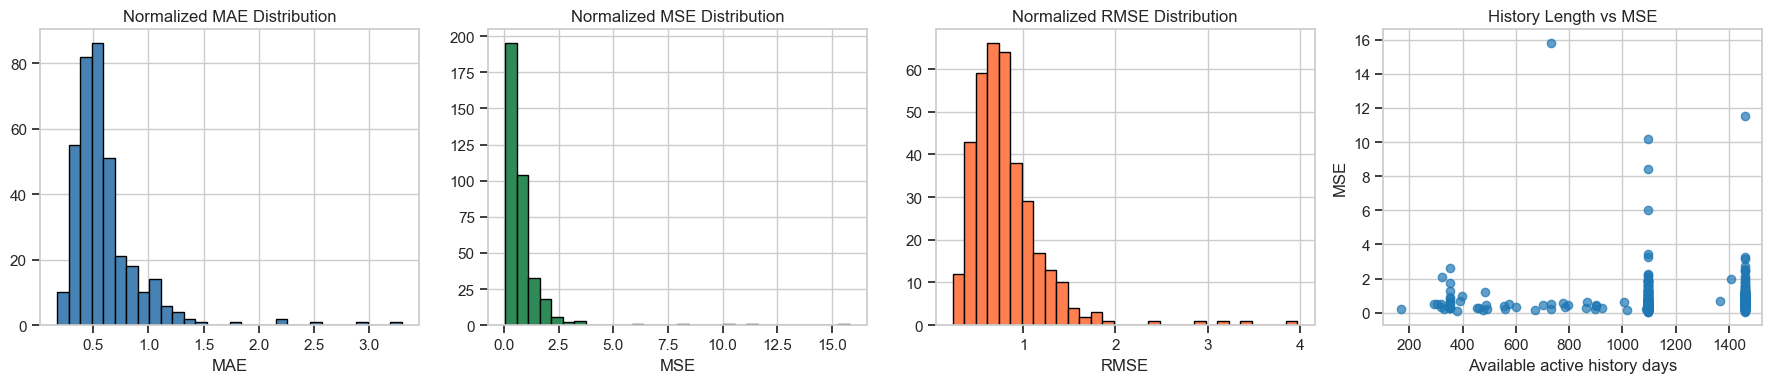

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

if len(successful_metrics) > 0:
    successful_metrics["mae"].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="black")
    axes[0].set_title("Normalized MAE Distribution")
    axes[0].set_xlabel("MAE")

    successful_metrics["mse"].hist(bins=30, ax=axes[1], color="seagreen", edgecolor="black")
    axes[1].set_title("Normalized MSE Distribution")
    axes[1].set_xlabel("MSE")

    successful_metrics["rmse"].hist(bins=30, ax=axes[2], color="coral", edgecolor="black")
    axes[2].set_title("Normalized RMSE Distribution")
    axes[2].set_xlabel("RMSE")

    axes[3].scatter(successful_metrics["history_days"], successful_metrics["mse"], alpha=0.7)
    axes[3].set_title("History Length vs MSE")
    axes[3].set_xlabel("Available active history days")
    axes[3].set_ylabel("MSE")
else:
    for ax in axes:
        ax.text(0.5, 0.5, "No successful models", ha="center", va="center")

plt.tight_layout()

In [17]:
if len(successful_metrics) > 0:
    result_cols = [
        "client", "n_obs", "lookback_window", "forecast_horizon",
        "mae", "mse", "rmse", "smape_pct",
    ]
    display(successful_metrics.nsmallest(10, "mse")[result_cols])
    display(successful_metrics.nlargest(10, "mse")[result_cols])

,client,n_obs,lookback_window,forecast_horizon,mae,mse,rmse,smape_pct
0,MT_151,105216,256,96,0.175466,0.055911,0.236455,34.299203
1,MT_362,105216,256,96,0.217639,0.064367,0.253706,47.425566
2,MT_229,140256,256,96,0.212951,0.066984,0.258814,30.679478
3,MT_246,140256,256,96,0.219336,0.080806,0.284264,36.356153
4,MT_155,105216,256,96,0.229510,0.093421,0.305648,56.776292
5,MT_027,105216,256,96,0.256615,0.106758,0.326739,58.376882
6,MT_070,105216,256,96,0.250919,0.109230,0.330499,65.063087
7,MT_313,140256,256,96,0.262459,0.113513,0.336917,44.106061
8,MT_034,105216,256,96,0.262097,0.114196,0.337929,63.190854
9,MT_062,105216,256,96,0.285039,0.119268,0.345352,65.541876


,client,n_obs,lookback_window,forecast_horizon,mae,mse,rmse,smape_pct
365,MT_370,70080,256,96,3.295931,15.811465,3.976363,196.571807
364,MT_288,140256,256,96,2.950849,11.516118,3.393541,141.969483
363,MT_119,105216,256,96,2.218392,10.188101,3.191880,88.400074
362,MT_140,105216,256,96,2.531345,8.417796,2.901344,157.961597
361,MT_157,105216,256,96,2.159664,6.036307,2.456890,126.922192
360,MT_366,105216,256,96,1.737362,3.464763,1.861388,125.445140
359,MT_162,140256,256,96,1.389894,3.288539,1.813433,133.912221
358,MT_130,105216,256,96,1.526326,3.237569,1.799324,149.521641
357,MT_331,140256,256,96,1.309926,3.164575,1.778925,106.455305
356,MT_209,140256,256,96,1.046746,2.717873,1.648597,105.798810


## 9. Normalized Holdout Forecast Examples

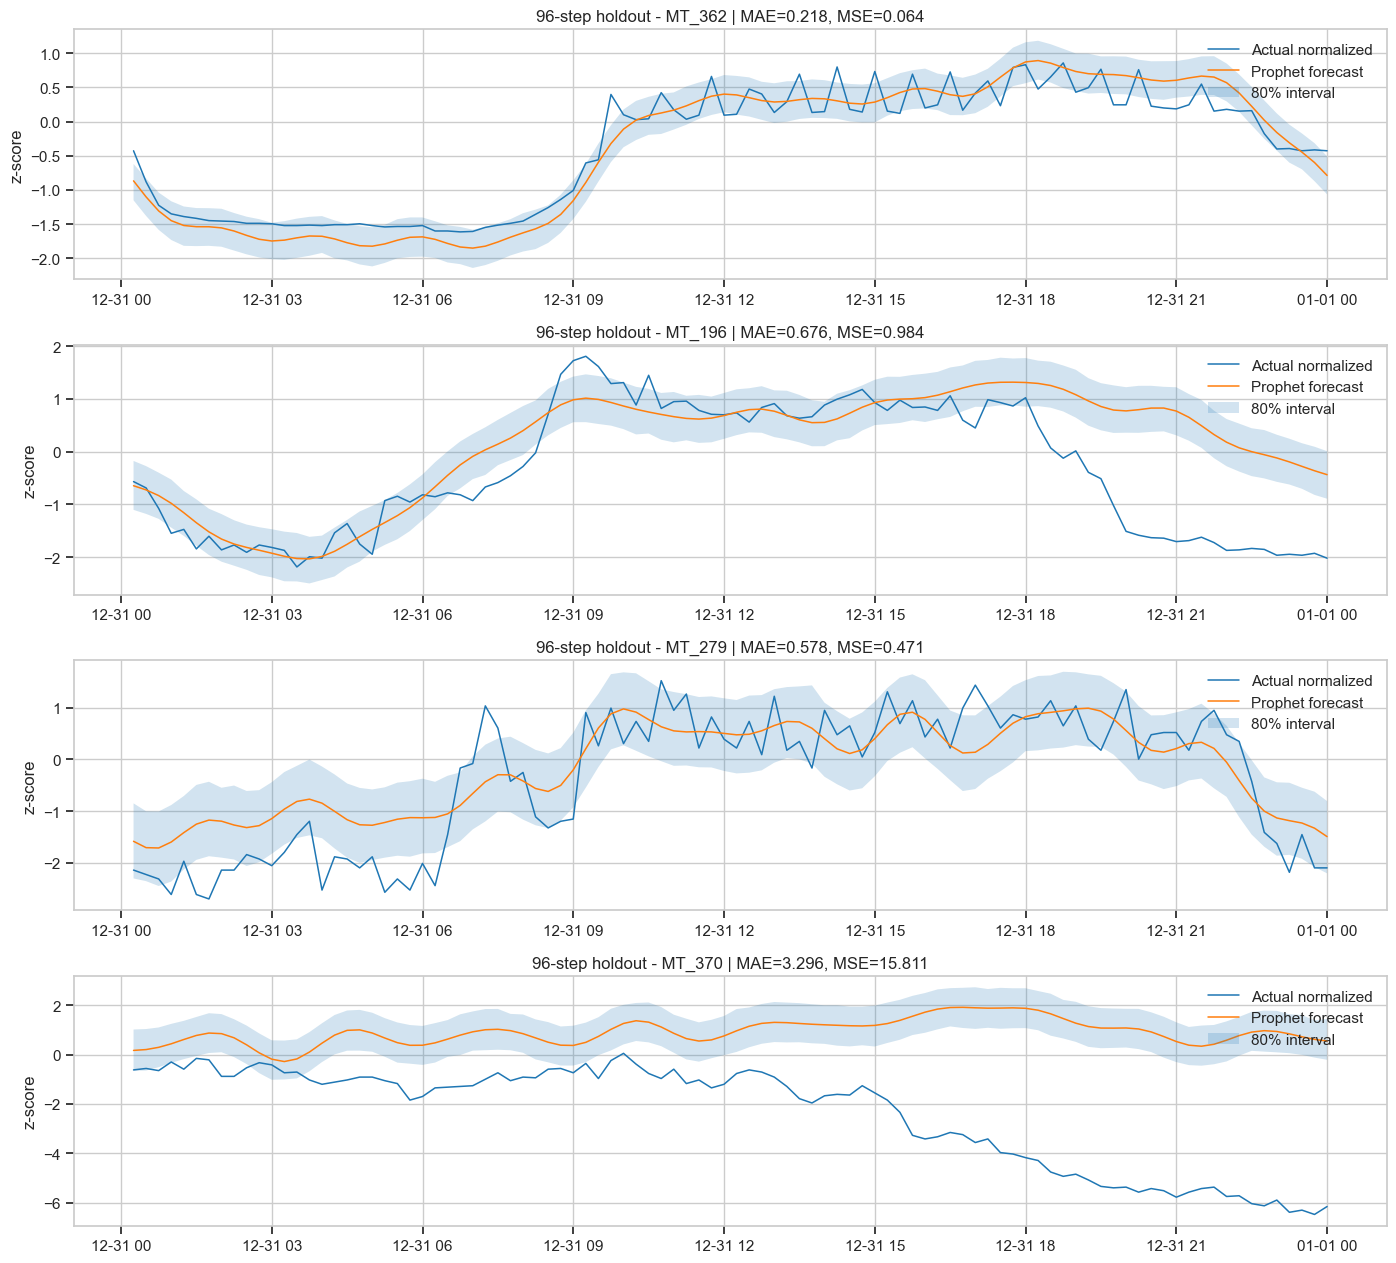

In [18]:
if len(successful_metrics) > 0 and not holdout_predictions_df.empty:
    example_clients = [c for c in top_clients if c in successful_metrics["client"].values][:4]
    if not example_clients:
        example_clients = successful_metrics.head(4)["client"].tolist()

    fig, axes = plt.subplots(len(example_clients), 1, figsize=(14, 3.2 * len(example_clients)), sharex=False)
    if len(example_clients) == 1:
        axes = [axes]

    for ax, client in zip(axes, example_clients):
        temp = holdout_predictions_df[holdout_predictions_df["client"] == client]
        ax.plot(temp["ds"], temp["y"], label="Actual normalized", linewidth=1.1)
        ax.plot(temp["ds"], temp["yhat"], label="Prophet forecast", linewidth=1.1)
        ax.fill_between(temp["ds"], temp["yhat_lower"], temp["yhat_upper"], alpha=0.2, label="80% interval")
        row = successful_metrics.loc[successful_metrics["client"] == client].iloc[0]
        ax.set_title(f"96-step holdout - {client} | MAE={row['mae']:.3f}, MSE={row['mse']:.3f}")
        ax.set_ylabel("z-score")
        ax.legend(loc="upper right")

    plt.tight_layout()

## 10. Normalized 96-Step Future Forecast Examples

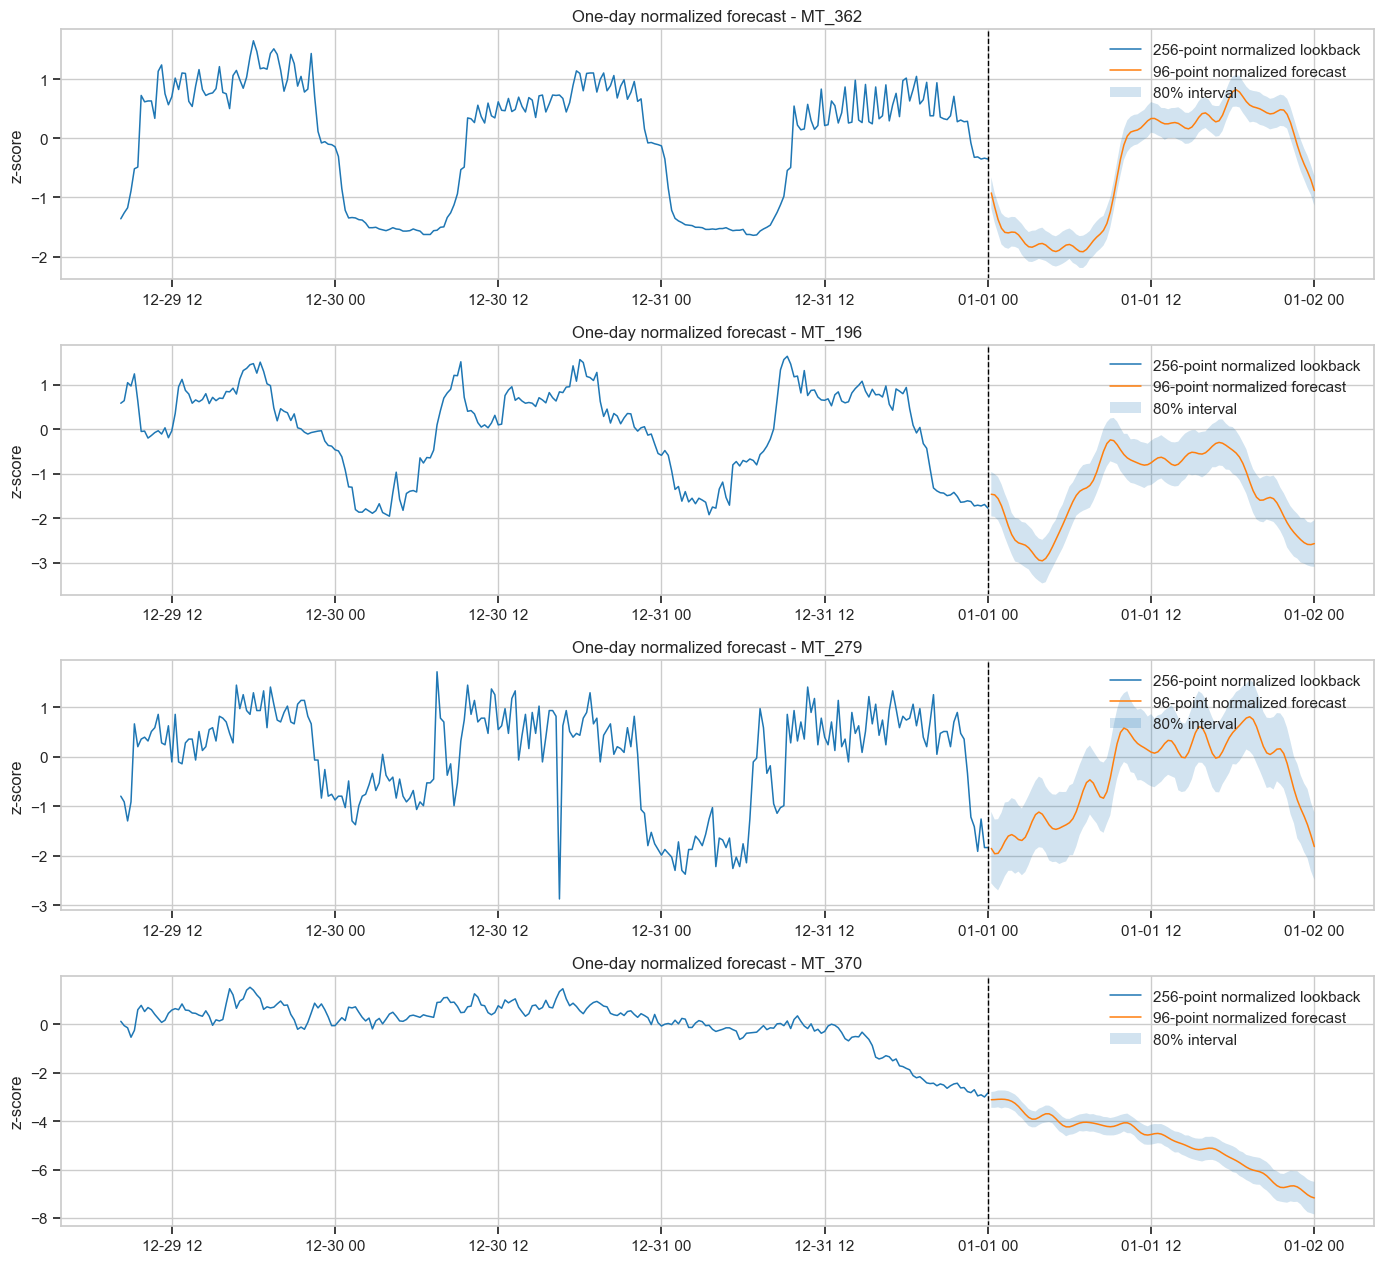

In [19]:
if len(successful_metrics) > 0 and not future_forecasts_df.empty:
    example_clients = [c for c in top_clients if c in successful_metrics["client"].values][:4]
    if not example_clients:
        example_clients = successful_metrics.head(4)["client"].tolist()

    fig, axes = plt.subplots(len(example_clients), 1, figsize=(14, 3.2 * len(example_clients)), sharex=False)
    if len(example_clients) == 1:
        axes = [axes]

    for ax, client in zip(axes, example_clients):
        original_history = prepare_client_frame(processed_15min, client).tail(LOOKBACK_WINDOW)
        metric_row = successful_metrics.loc[successful_metrics["client"] == client].iloc[0]
        final_scaler = {"mean": metric_row["final_mean"], "std": metric_row["final_std"]}
        history_tail = original_history[["ds"]].copy()
        history_tail["y"] = transform_values(original_history["y"], final_scaler)
        future_temp = future_forecasts_df[future_forecasts_df["client"] == client]

        ax.plot(history_tail["ds"], history_tail["y"], label="256-point normalized lookback", linewidth=1.1)
        ax.plot(future_temp["ds"], future_temp["yhat"], label="96-point normalized forecast", linewidth=1.1)
        ax.fill_between(future_temp["ds"], future_temp["yhat_lower"], future_temp["yhat_upper"], alpha=0.2, label="80% interval")
        ax.axvline(history_tail["ds"].max(), color="black", linestyle="--", linewidth=1)
        ax.set_title(f"One-day normalized forecast - {client}")
        ax.set_ylabel("z-score")
        ax.legend(loc="upper right")

    plt.tight_layout()

## 11. Saved Artifacts

CSV files:

- `outputs/prophet_all_normalized/prophet_all_normalized_metrics.csv`
- `outputs/prophet_all_normalized/prophet_all_normalized_holdout_predictions.csv`
- `outputs/prophet_all_normalized/prophet_all_normalized_future_forecasts.csv`
- `outputs/prophet_all_normalized/prophet_all_normalized_metrics_partial.csv`
- `outputs/prophet_all_normalized/prophet_all_normalized_scalers_full_history.csv`


In [20]:
for path in [
    OUTPUT_DIR / "prophet_all_normalized_metrics.csv",
    OUTPUT_DIR / "prophet_all_normalized_holdout_predictions.csv",
    OUTPUT_DIR / "prophet_all_normalized_future_forecasts.csv",
    OUTPUT_DIR / "prophet_all_normalized_metrics_partial.csv",
    OUTPUT_DIR / "prophet_all_normalized_scalers_full_history.csv",
]:
    print(f"{path}: {'exists' if path.exists() else 'not created yet'}")

outputs/prophet_all_normalized/prophet_all_normalized_metrics.csv: exists
outputs/prophet_all_normalized/prophet_all_normalized_holdout_predictions.csv: exists
outputs/prophet_all_normalized/prophet_all_normalized_future_forecasts.csv: exists
outputs/prophet_all_normalized/prophet_all_normalized_metrics_partial.csv: exists
outputs/prophet_all_normalized/prophet_all_normalized_scalers_full_history.csv: exists
